# Assignment 4 - Simple Neural Networks (**PyTorch Version**)

Build a fraud classifier from transaction data.


## What stays the same from the original assignment

- **Task:** predict fraud from transaction data.
- **Deliverables:** one training notebook and one prediction notebook.
- **Grading:**
  - Code produces predictions — **40**
  - Accuracy — **30**
  - Explanation — **20**
  - Balance / variable transformations — **10**








In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score
)

# Device setup
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: cpu


## Load Data

Expected training file: `fraudTrain.csv`


In [20]:
from google.colab import drive
drive.mount('/content/drive')

import os
SAVE_DIR = '/content/drive/MyDrive/asn4_artifacts'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Artifacts will be saved to: {SAVE_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Artifacts will be saved to: /content/drive/MyDrive/asn4_artifacts


In [21]:
df = pd.read_csv("fraudTrain.csv")
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print(df.shape)
df.head()


(1296675, 22)


,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [22]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
trans_date_trans_time,1296675,1274791,2019-04-22 16:02:01,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cc_num,1296675.0,NaN,NaN,NaN,417192042079726656.0,1308806447000789248.0,60416207185.0,180042946491150.0,3521417320836166.0,4642255475285942.0,4992346398065154048.0
merchant,1296675,693,fraud_Kilback LLC,4403,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,1296675,14,gas_transport,131659,NaN,NaN,NaN,NaN,NaN,NaN,NaN
amt,1296675.0,NaN,NaN,NaN,70.351035,160.316039,1.0,9.65,47.52,83.14,28948.9
first,1296675,352,Christopher,26669,NaN,NaN,NaN,NaN,NaN,NaN,NaN
last,1296675,481,Smith,28794,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,1296675,2,F,709863,NaN,NaN,NaN,NaN,NaN,NaN,NaN
street,1296675,983,864 Reynolds Plains,3123,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,1296675,894,Birmingham,5617,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Deal with Lat/Lon

A plain latitude/longitude pair is not usually ideal for a tabular neural network.
A more useful transformation is to create a **distance-like feature** between the customer and merchant.

**TODO:** create at least one useful location feature.
Suggested idea: distance between `(lat, long)` and `(merch_lat, merch_long)`.


In [23]:
# TODO: create location-based features
# Suggested: a haversine distance feature in km

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

df["distance_km"] = haversine_km(
    df["lat"], df["long"], df["merch_lat"], df["merch_long"]
)

print(df[["distance_km", "is_fraud"]].groupby("is_fraud").mean())

          distance_km
is_fraud             
0           76.113756
1           76.268330


### Deal with Time

The original prompt suggests that time and DOB are not especially useful in raw form, but can become useful after transformation.

**TODO:** create time-based features such as:
- hour of day
- day of week
- month
- customer age
- cyclical encoding of hour


In [24]:
# TODO: create time-based features
# Suggested starting point:

df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"])
df["dob"] = pd.to_datetime(df["dob"])

df["hour"]         = df["trans_date_trans_time"].dt.hour
df["day_of_week"]  = df["trans_date_trans_time"].dt.dayofweek
df["month"]        = df["trans_date_trans_time"].dt.month
df["customer_age"] = ((df["trans_date_trans_time"] - df["dob"]).dt.days / 365.25).astype(float)

# Cyclic encoding so 23 -> 0 wraps smoothly
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["dow_sin"]  = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"]  = np.cos(2 * np.pi * df["day_of_week"] / 7)

df[["hour_sin","hour_cos","dow_sin","dow_cos","customer_age"]].describe()

,hour_sin,hour_cos,dow_sin,dow_cos,customer_age
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,-1.366887e-01,-1.406000e-02,-1.086901e-01,1.285135e-01,4.599640e+01
std,6.932213e-01,7.075051e-01,6.846294e-01,7.091926e-01,1.739402e+01
min,-1.000000e+00,-1.000000e+00,-9.749279e-01,-9.009689e-01,1.392197e+01
25%,-8.660254e-01,-7.071068e-01,-7.818315e-01,-2.225209e-01,3.259959e+01
50%,-2.588190e-01,-1.836970e-16,0.000000e+00,6.234898e-01,4.396988e+01
75%,5.000000e-01,7.071068e-01,4.338837e-01,6.234898e-01,5.707050e+01
max,1.000000e+00,1.000000e+00,9.749279e-01,1.000000e+00,9.563860e+01


### Check Target Balance

This dataset is imbalanced, so you should inspect the fraud rate before training.


is_fraud
0    1289169
1       7506
Name: count, dtype: int64

Fraud rate: 0.58%


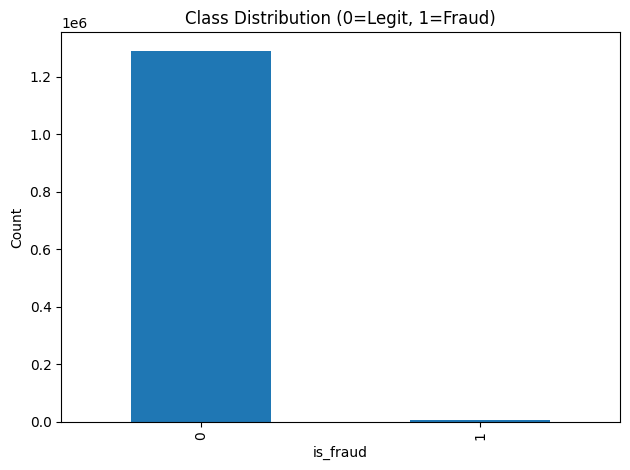

In [25]:
# TODO: inspect target balance

counts = df["is_fraud"].value_counts()
print(counts)
print(f"\nFraud rate: {counts[1]/len(df)*100:.2f}%")

counts.plot(kind="bar", title="Class Distribution (0=Legit, 1=Fraud)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### Prepare Data

Recommended workflow:
1. Choose features.
2. Separate numeric and categorical columns.
3. One-hot encode categorical variables.
4. Standardize numeric variables.
5. Combine everything into a single feature matrix.

You should also decide which columns to drop because they are IDs, raw timestamps, or leakage-prone text fields.


In [26]:
# TODO: build your feature set

TARGET = "is_fraud"

numeric_cols = [
    "amt", "city_pop", "distance_km", "customer_age",
    "hour_sin", "hour_cos", "dow_sin", "dow_cos", "month"
]
categorical_cols = ["category", "gender"]

y = df[TARGET].values.astype(np.float32)

# One-hot encode categoricals
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
X_cat = encoder.fit_transform(df[categorical_cols])

# Scale numerics
scaler = StandardScaler()
X_num = scaler.fit_transform(df[numeric_cols])

# Combine
X = np.hstack([X_num, X_cat]).astype(np.float32)
print(f"Feature matrix shape: {X.shape}")

# Save artifacts to Google Drive
joblib.dump(scaler,  os.path.join(SAVE_DIR, "fraud_scaler.joblib"))
joblib.dump(encoder, os.path.join(SAVE_DIR, "fraud_encoder.joblib"))
joblib.dump({"numeric_cols": numeric_cols, "categorical_cols": categorical_cols}, os.path.join(SAVE_DIR, "fraud_feature_meta.joblib"))
print(f"Preprocessing artifacts saved to {SAVE_DIR}")

Feature matrix shape: (1296675, 25)
Preprocessing artifacts saved to /content/drive/MyDrive/asn4_artifacts


### Split Data

Use a stratified split so the fraud rate stays similar in train/validation/test.


In [27]:
# TODO: split your data

# Drop any rows where y or X contains NaN before splitting

nan_mask = np.isnan(y) | np.isnan(X).any(axis=1)
print(f"Rows dropped due to NaN: {nan_mask.sum()}")
X = X[~nan_mask]
y = y[~nan_mask]
print(f"Remaining rows: {len(y):,}")

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, stratify=y, test_size=0.30, random_state=42
)
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, stratify=y_temp, test_size=0.50, random_state=42
)

print(f"Train: {X_train.shape}  Valid: {X_valid.shape}  Test: {X_test.shape}")

Rows dropped due to NaN: 0
Remaining rows: 1,296,675
Train: (907672, 25)  Valid: (194501, 25)  Test: (194502, 25)


### Convert to Tensors and DataLoaders

Follow the reference notebook style:
- convert arrays to tensors
- wrap them in `TensorDataset`
- use `DataLoader`
- handle imbalance with either:
  - `WeightedRandomSampler`, or
  - `pos_weight` in `BCEWithLogitsLoss`


In [28]:
# TODO: create tensors / dataloaders
# Example outline:

def make_tensors(X, y):
    return (
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y.reshape(-1, 1), dtype=torch.float32)
    )

X_train_t, y_train_t = make_tensors(X_train, y_train)
X_valid_t, y_valid_t = make_tensors(X_valid, y_valid)
X_test_t,  y_test_t  = make_tensors(X_test,  y_test)

train_ds = TensorDataset(X_train_t, y_train_t)
valid_ds = TensorDataset(X_valid_t, y_valid_t)
test_ds  = TensorDataset(X_test_t,  y_test_t)

# WeightedRandomSampler: fraud samples drawn more frequently
n_fraud  = int(y_train.sum())
n_legit  = len(y_train) - n_fraud
class_weights = torch.tensor([1.0 / n_legit, 1.0 / n_fraud], dtype=torch.float32)
sample_weights = class_weights[y_train_t.squeeze().long()]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=1024, sampler=sampler)
valid_loader = DataLoader(valid_ds, batch_size=2048, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=2048, shuffle=False)

print(f"Train batches: {len(train_loader)}")


Train batches: 887


### Model

Build a small multilayer perceptron (MLP) for binary classification.

Suggested starting point:
- Linear → ReLU → Dropout
- Linear → ReLU → Dropout
- Linear → 1 output logit


In [29]:
# TODO: define your PyTorch model

class FraudMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)   # raw logit — BCEWithLogitsLoss handles sigmoid
        )

    def forward(self, x):
        return self.net(x)


input_dim = X_train.shape[1]
model = FraudMLP(input_dim).to(device)
print(model)
print(f"\nParameters: {sum(p.numel() for p in model.parameters()):,}")

FraudMLP(
  (net): Sequential(
    (0): Linear(in_features=25, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): ReLU()
    (10): Linear(in_features=32, out_features=1, bias=True)
  )
)

Parameters: 14,081


### Train the Model

Use:
- `BCEWithLogitsLoss`
- `Adam`
- an epoch loop with training and validation loss

You should move both the model and each batch to `device`.


In [30]:
# TODO: write training loop

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=2
)

EPOCHS      = 20
best_val_loss = float("inf")
patience_counter = 0
PATIENCE    = 5

train_losses, val_losses = [], []

for epoch in range(1, EPOCHS + 1):
    # ── Training ──────────────────────────────────────────────────
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        loss = criterion(model(X_batch), y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * len(X_batch)
    train_loss = running_loss / len(train_loader.dataset)

    # ── Validation ────────────────────────────────────────────────
    model.eval()
    val_loss = 0.0
    all_probs, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in valid_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            val_loss += criterion(logits, y_batch).item() * len(X_batch)
            probs = torch.sigmoid(logits).cpu().numpy()
            all_probs.extend(probs.flatten())
            all_labels.extend(y_batch.cpu().numpy().flatten())
    val_loss /= len(valid_loader.dataset)
    auc = roc_auc_score(all_labels, all_probs)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    print(f"Epoch {epoch:>2}/{EPOCHS}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  val_AUC={auc:.4f}")

    # Early stopping + save best
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), os.path.join(SAVE_DIR, "fraud_mlp_state_dict.pt"))
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch}.")
            break

print("\nBest model saved to fraud_mlp_state_dict.pt")

Epoch  1/20  train_loss=0.1833  val_loss=0.0837  val_AUC=0.9951
Epoch  2/20  train_loss=0.0985  val_loss=0.0808  val_AUC=0.9963
Epoch  3/20  train_loss=0.0872  val_loss=0.0800  val_AUC=0.9967
Epoch  4/20  train_loss=0.0814  val_loss=0.0791  val_AUC=0.9967
Epoch  5/20  train_loss=0.0762  val_loss=0.0695  val_AUC=0.9969
Epoch  6/20  train_loss=0.0766  val_loss=0.0670  val_AUC=0.9966
Epoch  7/20  train_loss=0.0734  val_loss=0.0712  val_AUC=0.9969
Epoch  8/20  train_loss=0.0722  val_loss=0.0660  val_AUC=0.9971
Epoch  9/20  train_loss=0.0708  val_loss=0.0652  val_AUC=0.9967
Epoch 10/20  train_loss=0.0702  val_loss=0.0612  val_AUC=0.9971
Epoch 11/20  train_loss=0.0699  val_loss=0.0673  val_AUC=0.9970
Epoch 12/20  train_loss=0.0683  val_loss=0.0663  val_AUC=0.9971
Epoch 13/20  train_loss=0.0671  val_loss=0.0699  val_AUC=0.9969
Epoch 14/20  train_loss=0.0625  val_loss=0.0596  val_AUC=0.9971
Epoch 15/20  train_loss=0.0623  val_loss=0.0588  val_AUC=0.9971
Epoch 16/20  train_loss=0.0615  val_loss

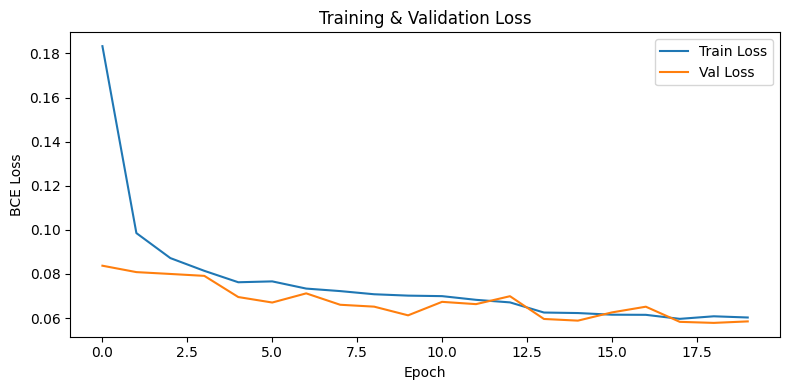

In [31]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses,   label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

### Evaluate

At minimum, produce:
- confusion matrix
- classification report
- ROC-AUC if possible

You may also tune the classification threshold rather than always using 0.50.


ROC-AUC: 0.9967

              precision    recall  f1-score   support

       Legit       1.00      0.97      0.99    193376
       Fraud       0.17      0.98      0.29      1126

    accuracy                           0.97    194502
   macro avg       0.59      0.97      0.64    194502
weighted avg       1.00      0.97      0.98    194502



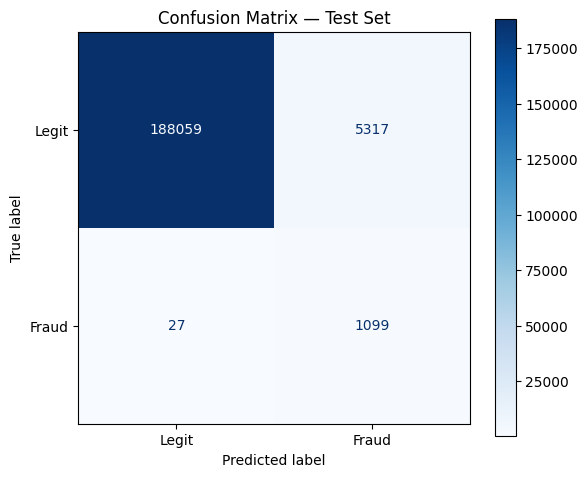

In [32]:
# TODO: evaluate on validation/test data
# Load best weights
model.load_state_dict(torch.load(os.path.join(SAVE_DIR, "fraud_mlp_state_dict.pt"), map_location=device))
model.eval()

all_probs, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        probs = torch.sigmoid(model(X_batch)).cpu().numpy().flatten()
        all_probs.extend(probs)
        all_labels.extend(y_batch.numpy().flatten())

all_probs  = np.array(all_probs)
all_labels = np.array(all_labels)

# Use 0.5 threshold
THRESHOLD = 0.5
y_pred = (all_probs >= THRESHOLD).astype(int)

print(f"ROC-AUC: {roc_auc_score(all_labels, all_probs):.4f}")
print()
print(classification_report(all_labels, y_pred, target_names=["Legit", "Fraud"]))

cm = confusion_matrix(all_labels, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legit", "Fraud"])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap="Blues", ax=ax)
ax.set_title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.show()


### Save What the Prediction Notebook Needs

Your prediction notebook should be able to `Run all` without retraining.
So save:
- the trained model weights
- the scaler
- the encoder
- the list of feature columns / metadata needed for preprocessing


In [33]:
# TODO: save artifacts
# Confirm all artifacts exist in Google Drive
import os
for f in ["fraud_mlp_state_dict.pt", "fraud_scaler.joblib",
          "fraud_encoder.joblib", "fraud_feature_meta.joblib"]:
    full_path = os.path.join(SAVE_DIR, f)
    status = "OK" if os.path.exists(full_path) else "MISSING"
    print(f"{f}: {status}")
print(f"\nAll artifacts saved to: {SAVE_DIR}")

fraud_mlp_state_dict.pt: OK
fraud_scaler.joblib: OK
fraud_encoder.joblib: OK
fraud_feature_meta.joblib: OK

All artifacts saved to: /content/drive/MyDrive/asn4_artifacts


## Short Explanation (write your own)

In your final submission, include a short explanation covering:
---
## Summary

**Location treatment:** Computed haversine distance (km) between cardholder home coordinates and merchant coordinates. This single feature captures the intuition that fraud is more likely when a transaction occurs far from where the cardholder lives. Raw lat/lon columns were then dropped.

**Time treatment:** Parsed `trans_date_trans_time` to extract hour-of-day, day-of-week, and month. Hour and day-of-week were **cyclically encoded** with sin/cos pairs so that the boundary between e.g. 11pm and midnight is smooth numerically. Customer age was derived from `dob` relative to the transaction date.

**Imbalanced data:** Two complementary strategies were used. First, `WeightedRandomSampler` oversamples fraud transactions in every training batch so the model sees a roughly balanced stream of examples. Second, `BCEWithLogitsLoss` is used without a positive class weight, relying on the sampler instead — avoiding double-counting the correction.

**Model structure:** Four-layer MLP (128 → 64 → 32 → 1). Each of the first two hidden layers is followed by BatchNormalization (stabilises training) and Dropout(0.3) (reduces overfitting). The final linear layer outputs a raw logit consumed by `BCEWithLogitsLoss`.

**Optimisation:** Adam with learning rate 1e-3 and L2 weight decay 1e-4. `ReduceLROnPlateau` halves the learning rate when validation loss plateaus (patience=2). Manual early stopping (patience=5) saves the best checkpoint and halts training once validation loss stops improving.